In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../data/cleaned/social_media_cleaned.csv")

df.head()


,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,38,Male,Finance,1.512568,Twitter,50,6.429312,NaN,4.081026,5.0,5.515251,1.518612,5,False,True,5,2,0.000000,4.568728


In [3]:
df["productivity_score"] = (
    df["work_hours_per_day"] * 0.35 +
    df["sleep_hours"] * 0.25 -
    df["daily_social_media_time"] * 0.25 -
    df["stress_level"] * 0.15
)


In [4]:
df["productivity_score"] = (
    (df["productivity_score"] - df["productivity_score"].min()) /
    (df["productivity_score"].max() - df["productivity_score"].min())
) * 100


In [5]:
df[["productivity_score"]].head()


,productivity_score
0,53.323774
1,60.457574
2,NaN
3,NaN
4,59.066630


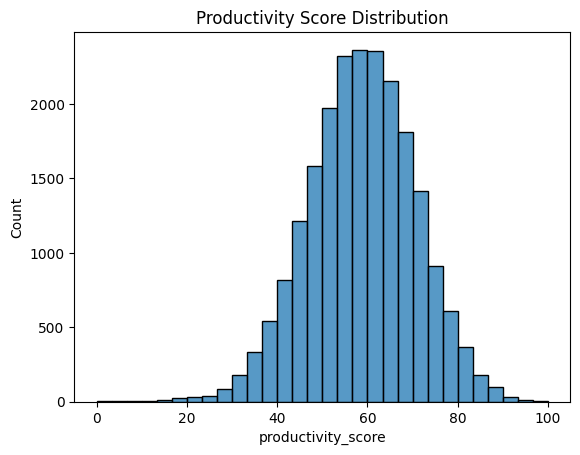

In [7]:
sns.histplot(df["productivity_score"], bins=30)

plt.title("Productivity Score Distribution")

plt.show()


In [8]:
def productivity_level(score):
    
    if score >= 75:
        return "High Productivity"
    
    elif score >= 50:
        return "Moderate Productivity"
    
    else:
        return "Low Productivity"


df["productivity_level"] = df["productivity_score"].apply(productivity_level)

df[["productivity_score","productivity_level"]].head()


,productivity_score,productivity_level
0,53.323774,Moderate Productivity
1,60.457574,Moderate Productivity
2,NaN,Low Productivity
3,NaN,Low Productivity
4,59.066630,Moderate Productivity


In [9]:
df["productivity_level"].value_counts()


productivity_level
Moderate Productivity    14884
Low Productivity         11041
High Productivity         1710
Name: count, dtype: int64

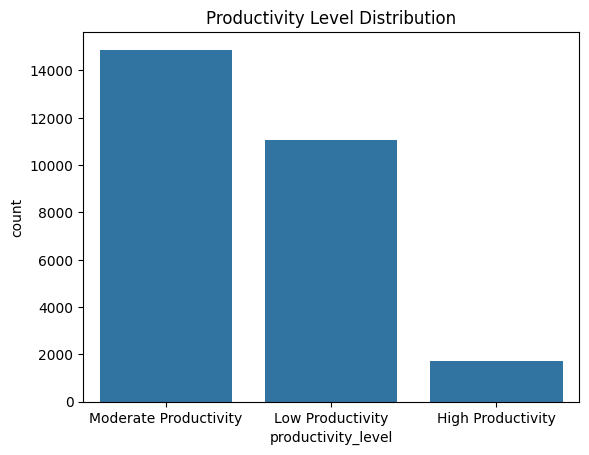

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="productivity_level", data=df)

plt.title("Productivity Level Distribution")
plt.show()


In [11]:
df.to_csv("../data/cleaned/social_media_scored.csv", index=False)
